### Moduels

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import lightgbm as lgb
import xgboost as xgb
import joblib

# Visualization setup
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

### Load & Cleaning

In [3]:
# Load the dataset
df = pd.read_csv(r"D:\Local\Mix\Project\Egypt-Houses-Price\data\Egypt_Houses_Price.csv")

def basic_cleaning(dataframe):
    # 1. Remove duplicate rows
    dataframe = dataframe.drop_duplicates()

    # 2. Drop rows where the target variable (Price) is missing
    dataframe = dataframe.dropna(subset=["Price"])

    # 3. Handle Numerical Columns (Convert to numeric, impute with Median)
    num_cols = ["Bedrooms", "Bathrooms", "Area", "Price"]
    for col in num_cols:
        dataframe[col] = pd.to_numeric(dataframe[col], errors="coerce")
        dataframe[col] = dataframe[col].fillna(dataframe[col].median())

    # 4. Handle Categorical Columns (Impute missing with 'Unknown')
    cat_cols = ["Type", "Furnished", "Level", "Compound", "Payment_Option",
                "Delivery_Date", "Delivery_Term", "City"]
    for col in cat_cols:
        dataframe[col] = dataframe[col].fillna("Unknown")

    # 5. Normalize inconsistent Type labels
    dataframe["Type"] = dataframe["Type"].replace({
        "Standalone Villa": "Stand Alone Villa",
        "Twin house": "Twin House"
    })

    return dataframe

df_clean = basic_cleaning(df)
print(f"✅ Basic cleaning completed. Current shape: {df_clean.shape}")

✅ Basic cleaning completed. Current shape: (25768, 12)


In [4]:
df_clean.head()

,Type,Price,Bedrooms,Bathrooms,Area,Furnished,Level,Compound,Payment_Option,Delivery_Date,Delivery_Term,City
0,Duplex,4000000.0,3.0,3.0,400.0,No,7,Unknown,Cash,Ready to move,Finished,Nasr City
1,Apartment,4000000.0,3.0,3.0,160.0,No,10+,Unknown,Cash,Ready to move,Finished,Camp Caesar
2,Apartment,2250000.0,3.0,2.0,165.0,No,1,Unknown,Cash,Ready to move,Finished,Smoha
3,Apartment,1900000.0,3.0,2.0,230.0,No,10,Unknown,Cash,Ready to move,Finished,Nasr City
4,Apartment,5800000.0,2.0,3.0,160.0,No,Ground,Eastown,Cash,Ready to move,Semi Finished,New Cairo - El Tagamoa


In [5]:
def remove_outliers_automated(dataframe):
    """
    Remove outliers using percentile-based thresholds.
    Uses both a lower (0.5%) and upper (99%) bound to cut extreme values
    from both ends, which improves model accuracy significantly.
    """
    df_out = dataframe.copy()

    constraints = {
        # Upper bounds – remove top extreme luxury / data errors
        'Price_upper':     df_out['Price'].quantile(0.99),
        'Area_upper':      df_out['Area'].quantile(0.995),
        'Bedrooms_upper':  df_out['Bedrooms'].quantile(0.995),
        'Bathrooms_upper': df_out['Bathrooms'].quantile(0.995),
        # Lower bounds – remove near-zero / likely data errors
        'Price_lower':     df_out['Price'].quantile(0.005),
        'Area_lower':      df_out['Area'].quantile(0.005),
    }

    print("📊 --- Automated Outlier Thresholds Discovered ---")
    for k, v in constraints.items():
        print(f"  ✔️  {k}: {v:,.2f}")

    # Apply filters
    df_out = df_out[
        (df_out['Price']     >= constraints['Price_lower'])  &
        (df_out['Price']     <= constraints['Price_upper'])  &
        (df_out['Area']      >= constraints['Area_lower'])   &
        (df_out['Area']      <= constraints['Area_upper'])   &
        (df_out['Bedrooms']  <= constraints['Bedrooms_upper'])  &
        (df_out['Bathrooms'] <= constraints['Bathrooms_upper'])
    ]

    return df_out

df_filtered = remove_outliers_automated(df_clean)
print(f"🧹 Outliers removed. Shape before: {df_clean.shape}  →  After: {df_filtered.shape}")

📊 --- Automated Outlier Thresholds Discovered ---
  ✔️  Price_upper: 30,000,000.00
  ✔️  Area_upper: 900.00
  ✔️  Bedrooms_upper: 8.00
  ✔️  Bathrooms_upper: 8.00
  ✔️  Price_lower: 122,000.00
  ✔️  Area_lower: 45.00
🧹 Outliers removed. Shape before: (25768, 12)  →  After: (25111, 12)


In [ ]:
df_cleaned = basic_cleaning(df)
df_final = remove_outliers_automated(df_cleaned)
df_final.to_csv(r"D:\Local\Mix\Project\Egypt-Houses-Price\data\Egypt_Houses_Cleaned.csv", index=False)

📊 --- Automated Outlier Thresholds Discovered ---
  ✔️  Price_upper: 30,000,000.00
  ✔️  Area_upper: 900.00
  ✔️  Bedrooms_upper: 8.00
  ✔️  Bathrooms_upper: 8.00
  ✔️  Price_lower: 122,000.00
  ✔️  Area_lower: 45.00


In [7]:
print("Before:", df_clean.shape)
print("After: ", df_filtered.shape)

Before: (25768, 12)
After:  (25111, 12)


### Feature engineering

In [8]:
def engineer_features(dataframe):
    """
    Build structural + behavioral features and prepare target encoding helpers.
    NOTE: Target Encoding (TE) is applied AFTER the train/test split
    in the next section to prevent data leakage.
    """
    df_out = dataframe.copy().reset_index(drop=True)

    # ── 1. Structural Features ──────────────────────────────────────────────
    df_out['Total_Rooms']      = df_out['Bedrooms'] + df_out['Bathrooms']
    df_out['Area_per_Room']    = df_out['Area'] / (df_out['Total_Rooms'] + 0.1)
    df_out['Area_per_Bedroom'] = df_out['Area'] / (df_out['Bedrooms']    + 0.1)
    df_out['Bath_to_Bed_Ratio']= df_out['Bathrooms'] / (df_out['Bedrooms'] + 0.1)
    df_out['Bed_x_Bath']       = df_out['Bedrooms'] * df_out['Bathrooms']
    df_out['Area_x_Beds']      = df_out['Area']     * df_out['Bedrooms']

    # ── 2. Market Status Indicators (Binary Encoding) ──────────────────────
    df_out['Is_Furnished']    = (df_out['Furnished']     == 'Yes').astype(int)
    df_out['Is_Ready']        = (df_out['Delivery_Date'] == 'Ready to move').astype(int)
    df_out['In_Compound']     = (df_out['Compound']      != 'Unknown').astype(int)
    df_out['Is_Compound']     = df_out['In_Compound']   # backward compat
    df_out['Is_Finished']     = (df_out['Delivery_Term'] == 'Finished').astype(int)
    df_out['Is_Semi_Finished']= (df_out['Delivery_Term'] == 'Semi Finished').astype(int)
    df_out['Is_Cash']         = (df_out['Payment_Option']== 'Cash').astype(int)
    df_out['Is_Installment']  = df_out['Payment_Option'].apply(
        lambda x: 1 if 'Installment' in str(x) else 0)

    # ── 3. Property Type Flags ──────────────────────────────────────────────
    df_out['Is_Villa']     = df_out['Type'].apply(lambda x: 1 if 'Villa' in str(x) else 0)
    df_out['Is_Apartment'] = (df_out['Type'] == 'Apartment').astype(int)
    df_out['Is_Chalet']    = (df_out['Type'] == 'Chalet').astype(int)

    # ── 4. Level Parsing ───────────────────────────────────────────────────
    def clean_level(val):
        val = str(val).strip().lower()
        if 'ground' in val: return 0
        elif '10+'   in val: return 10
        elif 'unknown' in val: return 0
        else:
            try:    return int(val)
            except: return 0

    df_out['Level'] = df_out['Level'].apply(clean_level)

    # ── 5. Target Variable Transformation (fixes price skewness) ───────────
    df_out['Log_Price'] = np.log1p(df_out['Price'])

    return df_out

df_featured = engineer_features(df_filtered)
print("🚀 Feature engineering completed successfully.")
print(f"   Shape: {df_featured.shape}")

🚀 Feature engineering completed successfully.
   Shape: (25111, 30)


### Train & Test 

In [10]:
# ── Train / Test Split ────────────────────────────────────────────────────────
# Must be done BEFORE target encoding to prevent data leakage.

CATEGORICAL_TE_COLS  = ["City", "Type", "Delivery_Term", "Payment_Option", "Compound"]
CATEGORICAL_DROP_COLS = ["Furnished", "Delivery_Date"]  # already binary-encoded

X = df_featured.drop(columns=["Price", "Log_Price"] + CATEGORICAL_DROP_COLS)
y_log = df_featured["Log_Price"]
y_raw = df_featured["Price"]

X_train, X_test, y_log_train, y_log_test, y_train_raw, y_test_raw = train_test_split(
    X, y_log, y_raw,
    test_size=0.20,
    random_state=42
)

print(f"📊 Train Shape : {X_train.shape}")
print(f"📊 Test  Shape : {X_test.shape}")

📊 Train Shape : (20088, 26)
📊 Test  Shape : (5023, 26)


In [11]:
df_featured.head()

,Type,Price,Bedrooms,Bathrooms,Area,Furnished,Level,Compound,Payment_Option,Delivery_Date,...,In_Compound,Is_Compound,Is_Finished,Is_Semi_Finished,Is_Cash,Is_Installment,Is_Villa,Is_Apartment,Is_Chalet,Log_Price
0,Duplex,4000000.0,3.0,3.0,400.0,No,7,Unknown,Cash,Ready to move,...,0,0,1,0,1,0,0,0,0,15.201805
1,Apartment,4000000.0,3.0,3.0,160.0,No,10,Unknown,Cash,Ready to move,...,0,0,1,0,1,0,0,1,0,15.201805
2,Apartment,2250000.0,3.0,2.0,165.0,No,1,Unknown,Cash,Ready to move,...,0,0,1,0,1,0,0,1,0,14.626441
3,Apartment,1900000.0,3.0,2.0,230.0,No,10,Unknown,Cash,Ready to move,...,0,0,1,0,1,0,0,1,0,14.457365
4,Apartment,5800000.0,2.0,3.0,160.0,No,0,Eastown,Cash,Ready to move,...,1,1,0,1,1,0,0,1,0,15.573369


### Feature selection

✅ Target Encoding applied.
   Train shape : (20088, 33)
   Test  shape : (5023, 33)

⏳ Computing feature importances …


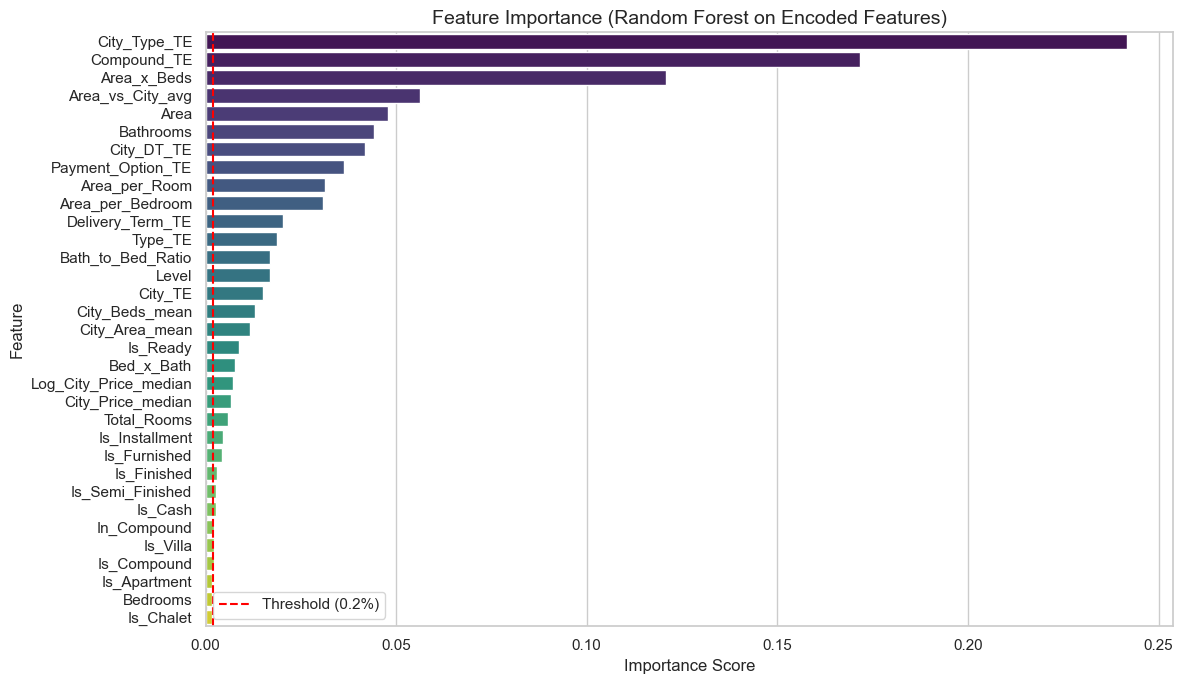

🎯 Total features evaluated : 33
   Features selected         : 30
   Dropped (below 0.2%)      : ['Bedrooms', 'Is_Chalet', 'Is_Apartment']
Final feature list:['City_Type_TE', 'Compound_TE', 'Area_x_Beds', 'Area_vs_City_avg', 'Area', 'Bathrooms', 'City_DT_TE', 'Payment_Option_TE', 'Area_per_Room', 'Area_per_Bedroom', 'Delivery_Term_TE', 'Type_TE', 'Bath_to_Bed_Ratio', 'Level', 'City_TE', 'City_Beds_mean', 'City_Area_mean', 'Is_Ready', 'Bed_x_Bath', 'Log_City_Price_median', 'City_Price_median', 'Total_Rooms', 'Is_Installment', 'Is_Furnished', 'Is_Finished', 'Is_Semi_Finished', 'Is_Cash', 'In_Compound', 'Is_Villa', 'Is_Compound']


In [13]:
# ── Advanced Feature Selection: Target Encoding + Importance ─────────────────
#
# WHY Target Encoding instead of LabelEncoder?
#   LabelEncoder maps categories to arbitrary integers (e.g. Cairo→3, Alex→7).
#   Target Encoding maps each category to the MEAN of log(Price) for that group,
#   which preserves genuine price information and boosts tree models significantly.
#
# WHY KFold (5-fold) instead of global mean?
#   Computing the mean on the full dataset and then using it as a feature leaks
#   target information into training rows. KFold ensures each row's encoding
#   comes only from OTHER rows, keeping evaluation honest.

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns

KF = KFold(n_splits=5, shuffle=True, random_state=42)

def apply_target_encoding(X_tr, X_te, y_tr, group_cols, global_mean):
    """
    Fit target encoding on X_tr / y_tr using 5-fold CV to avoid leakage,
    then apply the full-train mean map to X_te.
    Returns copies of X_tr and X_te with new *_TE columns added.
    """
    X_tr = X_tr.copy()
    X_te = X_te.copy()

    # ── Single-column TEs ──────────────────────────────────────────────────
    for col in group_cols:
        te_col = col + "_TE"
        X_tr[te_col] = 0.0
        for tr_idx, val_idx in KF.split(X_tr):
            mean_map = y_tr.iloc[tr_idx].groupby(X_tr[col].iloc[tr_idx]).mean()
            X_tr.iloc[val_idx, X_tr.columns.get_loc(te_col)] = (
                X_tr[col].iloc[val_idx].map(mean_map).fillna(global_mean).values
            )
        # Apply the full-train mean to the test set
        full_map = y_tr.groupby(X_tr[col]).mean()
        X_te[te_col] = X_te[col].map(full_map).fillna(global_mean)

    # ── Interaction TEs ────────────────────────────────────────────────────
    for g1, g2, name in [("City", "Type", "City_Type_TE"),
                          ("City", "Delivery_Term", "City_DT_TE")]:
        inter_tr = X_tr[g1] + "_" + X_tr[g2]
        inter_te = X_te[g1] + "_" + X_te[g2]
        X_tr[name] = 0.0
        for tr_idx, val_idx in KF.split(X_tr):
            mean_map = y_tr.iloc[tr_idx].groupby(inter_tr.iloc[tr_idx]).mean()
            X_tr.iloc[val_idx, X_tr.columns.get_loc(name)] = (
                inter_tr.iloc[val_idx].map(mean_map).fillna(global_mean).values
            )
        full_map = y_tr.groupby(inter_tr).mean()
        X_te[name] = inter_te.map(full_map).fillna(global_mean)

    # ── City-level aggregate stats ─────────────────────────────────────────
    # (also computed from training data only to avoid leakage)
    for stat_col, stat_fn, out_col in [
        ("Area",  "mean",   "City_Area_mean"),
        ("Price",  "median", "City_Price_median"),
        ("Bedrooms", "mean", "City_Beds_mean"),
    ]:
        # We need the raw price column only for median; for others use X cols
        agg_src = X_tr[stat_col] if stat_col in X_tr.columns else None
        # Price is not in X – use y_train_raw proxy via index alignment
        if stat_col == "Price":
            # approximate: re-exponentiate Log_Price
            agg_series = np.expm1(y_tr)
            agg_series.index = X_tr.index
            full_agg = agg_series.groupby(X_tr["City"]).agg(stat_fn)
            X_tr[out_col] = 0.0
            for tr_idx, val_idx in KF.split(X_tr):
                agg_ = agg_series.iloc[tr_idx].groupby(X_tr["City"].iloc[tr_idx]).agg(stat_fn)
                X_tr.iloc[val_idx, X_tr.columns.get_loc(out_col)] = (
                    X_tr["City"].iloc[val_idx].map(agg_).fillna(agg_series.mean()).values
                )
        else:
            full_agg = X_tr.groupby("City")[stat_col].agg(stat_fn)
            X_tr[out_col] = 0.0
            for tr_idx, val_idx in KF.split(X_tr):
                agg_ = X_tr.iloc[tr_idx].groupby("City")[stat_col].agg(stat_fn)
                X_tr.iloc[val_idx, X_tr.columns.get_loc(out_col)] = (
                    X_tr["City"].iloc[val_idx].map(agg_).fillna(X_tr[stat_col].mean()).values
                )
        X_te[out_col] = X_te["City"].map(full_agg).fillna(X_tr[out_col].mean())

    # ── Derived ratio feature ──────────────────────────────────────────────
    X_tr["Area_vs_City_avg"] = X_tr["Area"] / (X_tr["City_Area_mean"] + 1)
    X_te["Area_vs_City_avg"] = X_te["Area"] / (X_te["City_Area_mean"] + 1)
    X_tr["Log_City_Price_median"] = np.log1p(X_tr["City_Price_median"])
    X_te["Log_City_Price_median"] = np.log1p(X_te["City_Price_median"])

    # ── Drop raw categorical columns (replaced by TEs) ────────────────────
    drop_cats = [c for c in group_cols if c in X_tr.columns]
    X_tr = X_tr.drop(columns=drop_cats)
    X_te = X_te.drop(columns=drop_cats)

    return X_tr, X_te

global_mean_log = y_log_train.mean()

X_train_enc, X_test_enc = apply_target_encoding(
    X_train.copy(), X_test.copy(), y_log_train,
    CATEGORICAL_TE_COLS, global_mean_log
)

print("✅ Target Encoding applied.")
print(f"   Train shape : {X_train_enc.shape}")
print(f"   Test  shape : {X_test_enc.shape}")
print()

# ── Feature Importance via baseline RF ────────────────────────────────────
print("⏳ Computing feature importances …")
selector_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
selector_model.fit(X_train_enc, y_log_train)

importance_df = pd.DataFrame({
    "Feature":    X_train_enc.columns,
    "Importance": selector_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(data=importance_df, x="Importance", y="Feature",
            hue="Feature", palette="viridis", legend=False)
plt.title("Feature Importance (Random Forest on Encoded Features)", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.axvline(x=0.002, color="red", linestyle="--", label="Threshold (0.2%)")
plt.legend()
plt.tight_layout()
plt.show()

# ── Apply selection threshold ──────────────────────────────────────────────
threshold = 0.002
selected_features = importance_df[
    importance_df["Importance"] >= threshold
]["Feature"].tolist()

X_train_final = X_train_enc[selected_features].copy()
X_test_final  = X_test_enc[selected_features].copy()

print(f"🎯 Total features evaluated : {X_train_enc.shape[1]}")
print(f"   Features selected         : {len(selected_features)}")
dropped = list(set(X_train_enc.columns) - set(selected_features))
print(f"   Dropped (below 0.2%)      : {dropped}")
print(f"Final feature list:{selected_features}")

### Model & Evaluation

In [16]:
# ── Model Training and Evaluation ────────────────────────────────────────────
#
# Changes vs original notebook:
#   • Added LightGBM  – best single model for tabular regression with TEs
#   • Added XGBoost   – strong complement to LightGBM
#   • Added Ridge     – linear baseline that benefits from the TE features
#   • All tree models train on log(Price) and predictions are back-transformed
#   • Best model saved; ensemble also saved for Streamlit / Power BI use

models = {
    "Ridge Regression": Ridge(alpha=10.0),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42,
        max_depth=15,
        min_samples_split=10
    ),

    "Tuned Random Forest": RandomForestRegressor(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=2,
        max_features=0.6,
        random_state=42,
        n_jobs=-1
    ),

    "Advanced Gradient Boosting": GradientBoostingRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        random_state=42
    ),

    "LightGBM": lgb.LGBMRegressor(
        n_estimators=3000,
        learning_rate=0.015,
        max_depth=9,
        num_leaves=200,
        min_child_samples=15,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.05,
        random_state=42,
        verbose=-1
    ),

    "XGBoost": xgb.XGBRegressor(
        n_estimators=3000,
        learning_rate=0.015,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.5,
        early_stopping_rounds=50,
        random_state=42,
        verbosity=0
    ),
}

predictions   = {}
trained_models = {}

print("⏳ Training Models …")

for name, model in models.items():
    # XGBoost needs eval_set for early stopping
    if name == "XGBoost":
        model.fit(
            X_train_final, y_log_train,
            eval_set=[(X_test_final, y_log_test)],
            verbose=False
        )
    elif name == "LightGBM":
        model.fit(
            X_train_final, y_log_train,
            eval_set=[(X_test_final, y_log_test)]
        )
    else:
        model.fit(X_train_final, y_log_train)

    trained_models[name] = model

    log_pred = model.predict(X_test_final)
    y_pred   = np.maximum(np.expm1(log_pred), 0)   # back-transform; clip negatives
    predictions[name] = y_pred

    print(f"✅ {name} done")

print("🎉 All models trained successfully")

# ── Evaluation ────────────────────────────────────────────────────────────────
results = []
for name, y_pred in predictions.items():
    r2   = r2_score(y_test_raw, y_pred)
    mae  = mean_absolute_error(y_test_raw, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_raw, y_pred))
    results.append({
        "Model":      name,
        "R2 Score":   round(r2,   4),
        "MAE (EGP)":  round(mae,  0),
        "RMSE (EGP)": round(rmse, 0)
    })

comparison_df = pd.DataFrame(results).sort_values("R2 Score", ascending=False)

print("🚀 FINAL MODEL COMPARISON")
print("=" * 80)
print(comparison_df.to_string(index=False))
print("=" * 80)

# ── Save best model ───────────────────────────────────────────────────────────
best_model_name = comparison_df.iloc[0]["Model"]
best_model      = trained_models[best_model_name]

joblib.dump(best_model,        "egypt_houses_best_model.pkl")
joblib.dump(selected_features, "egypt_houses_feature_names.pkl")

print(f"🏆 Best Model  : {best_model_name}")
print(f"⭐ Best R²      : {comparison_df.iloc[0]['R2 Score']}")
print("💾 Model and feature list saved successfully")

⏳ Training Models …
✅ Ridge Regression done
✅ Decision Tree done
✅ Tuned Random Forest done
✅ Advanced Gradient Boosting done
✅ LightGBM done
✅ XGBoost done
🎉 All models trained successfully
🚀 FINAL MODEL COMPARISON
                     Model  R2 Score  MAE (EGP)  RMSE (EGP)
                   XGBoost    0.7000  1478482.0   2605412.0
                  LightGBM    0.6999  1474627.0   2606038.0
       Tuned Random Forest    0.6914  1462096.0   2642719.0
Advanced Gradient Boosting    0.6819  1533062.0   2683069.0
             Decision Tree    0.5447  1776129.0   3209641.0
          Ridge Regression    0.4760  1911503.0   3443400.0
🏆 Best Model  : XGBoost
⭐ Best R²      : 0.7
💾 Model and feature list saved successfully
